In [1]:
from typing_extensions import TypedDict
from langgraph.graph import StateGraph, START, END
from langchain_groq import ChatGroq
from dotenv import load_dotenv

In [2]:
load_dotenv()

True

In [3]:
class ParentState(TypedDict):
    question: str
    answer_eng: str
    answer_hin: str

In [4]:
parent_llm = ChatGroq(model= "llama-3.1-8b-instant")
subgraph_llm = ChatGroq(model= "llama-3.1-8b-instant")

In [6]:
def translate_text(state: ParentState):
    prompt = f"""
        Translate the following text to Hindi.
        Keep it natural and clear. Do not add extra content.

        Text:
        {state["answer_eng"]}
        """.strip()
    
    translated_text = parent_llm.invoke(prompt).content

    return {'answer_hin': translated_text}

In [7]:
subgraph_builder = StateGraph(ParentState)

subgraph_builder.add_node("translate_text", translate_text)

subgraph_builder.add_edge(START, 'translate_text')
subgraph_builder.add_edge('translate_text', END)

subgraph = subgraph_builder.compile()

In [8]:
def generate_answer(state: ParentState):

    answer = parent_llm.invoke(f"You are a helpful assistant. Answer clearly.\n\nQuestion: {state['question']}").content
    return {'answer_eng': answer}

In [9]:
parent_builder = StateGraph(ParentState)

parent_builder.add_node("generate_answer", generate_answer)
parent_builder.add_node("translate", subgraph)

parent_builder.add_edge(START, "generate_answer")
parent_builder.add_edge("generate_answer", 'translate')
parent_builder.add_edge("translate", END)

graph = parent_builder.compile()

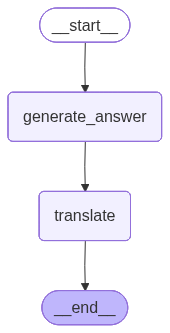

In [10]:
graph

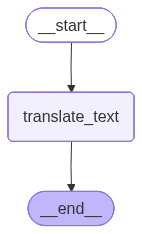

In [11]:
subgraph

In [12]:
graph.invoke({'question': 'What is quantum physics. In brief'})

{'question': 'What is quantum physics. In brief',
 'answer_eng': 'Quantum physics, also known as quantum mechanics, is a branch of physics that studies the behavior of matter and energy at an atomic and subatomic level. It explains how tiny particles like electrons, photons, and atoms can exhibit strange and seemingly random behavior, like:\n\n- Existing in multiple states at the same time (superposition)\n- Being connected and influencing each other even when separated (entanglement)\n- Exhibiting wave-like properties\n\nQuantum physics is a fundamental theory that helps us understand the behavior of the tiny building blocks of our universe.',
 'answer_hin': 'व्यावहारिक भौतिकी को क्वांटम भौतिकी या क्वांटम यांत्रिकी भी कहा जाता है, जो परमाणु और उप-परमाणु स्तर पर पदार्थ और ऊर्जा के व्यवहार का अध्ययन करती है। यह बताती है कि छोटे कण जैसे कि इलेक्ट्रॉन, फोटॉन और परमाणु कैसे असामान्य और दिखने वाले सุ่चित व्यवहार प्रदर्शित कर सकते हैं, जैसे कि:\n\n- एक ही समय में कई अवस्थाओं में मौजूद होना (